In [12]:
"""
=============================================================================
  INDIA UNEMPLOYMENT ANALYSIS — COVID-19 IMPACT STUDY
  Author  : Senior Data Analyst (15+ years experience)
  Datasets: Unemployment_in_India.csv
            Unemployment_Rate_upto_11_2020.csv
=============================================================================
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0. IMPORTS & GLOBAL SETTINGS
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates  as mdates
import seaborn           as sns

from matplotlib.gridspec  import GridSpec
from matplotlib.patches   import FancyArrowPatch, Patch
from matplotlib.lines     import Line2D

# ── Aesthetic theme ──────────────────────────────────────────────────────────
PALETTE = {
    "bg"        : "#0D1117",
    "panel"     : "#161B22",
    "border"    : "#30363D",
    "accent1"   : "#58A6FF",   # blue
    "accent2"   : "#F78166",   # coral/red  (crisis)
    "accent3"   : "#3FB950",   # green      (recovery)
    "accent4"   : "#D2A8FF",   # lavender
    "text"      : "#C9D1D9",
    "subtext"   : "#8B949E",
    "highlight" : "#E3B341",   # gold
}

plt.rcParams.update({
    "figure.facecolor"  : PALETTE["bg"],
    "axes.facecolor"    : PALETTE["panel"],
    "axes.edgecolor"    : PALETTE["border"],
    "axes.labelcolor"   : PALETTE["text"],
    "axes.titlecolor"   : PALETTE["text"],
    "xtick.color"       : PALETTE["subtext"],
    "ytick.color"       : PALETTE["subtext"],
    "text.color"        : PALETTE["text"],
    "grid.color"        : PALETTE["border"],
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.6,
    "figure.dpi"        : 130,
    "font.family"       : "DejaVu Sans",
    "legend.framealpha" : 0.3,
    "legend.edgecolor"  : PALETTE["border"],
})


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. DATA LOADING & CLEANING
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  STEP 1 — DATA LOADING & CLEANING")
print("=" * 65)

# --- Dataset 1: region-level with Rural/Urban split -------------------------
df1 = pd.read_csv("Unemployment_in_India.csv")
df1.columns = df1.columns.str.strip()
df1 = df1.rename(columns={
    "Region"                              : "Region",
    "Date"                                : "Date",
    "Frequency"                           : "Frequency",
    "Estimated Unemployment Rate (%)"     : "Unemployment_Rate",
    "Estimated Employed"                  : "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation",
    "Area"                                : "Area",
})
df1["Date"] = pd.to_datetime(df1["Date"].str.strip(), dayfirst=True)
df1 = df1.dropna(subset=["Region", "Date", "Unemployment_Rate"])
df1["Region"]           = df1["Region"].str.strip()
df1["Area"]             = df1["Area"].str.strip()
df1["Unemployment_Rate"] = pd.to_numeric(df1["Unemployment_Rate"], errors="coerce")
df1["Employed"]          = pd.to_numeric(df1["Employed"],          errors="coerce")
df1["Labour_Participation"] = pd.to_numeric(df1["Labour_Participation"], errors="coerce")
df1 = df1.dropna(subset=["Unemployment_Rate"])

# --- Dataset 2: extended timeline + geo coordinates -------------------------
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df2.columns = df2.columns.str.strip()

# The CSV has two 'Region' columns; rename carefully
cols = list(df2.columns)
# Rename the 7th column (index 6) which is the Zone (North/South/etc.)
cols[6] = "Zone"
df2.columns = cols

df2 = df2.rename(columns={
    "Region"                              : "Region",
    "Date"                                : "Date",
    "Frequency"                           : "Frequency",
    "Estimated Unemployment Rate (%)"     : "Unemployment_Rate",
    "Estimated Employed"                  : "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation",
})
df2["Date"] = pd.to_datetime(df2["Date"].str.strip(), dayfirst=True)
df2["Region"]             = df2["Region"].str.strip()
df2["Zone"]               = df2["Zone"].str.strip()
df2["Unemployment_Rate"]  = pd.to_numeric(df2["Unemployment_Rate"], errors="coerce")
df2["Employed"]           = pd.to_numeric(df2["Employed"],          errors="coerce")
df2["Labour_Participation"] = pd.to_numeric(df2["Labour_Participation"], errors="coerce")
df2["longitude"]          = pd.to_numeric(df2["longitude"],         errors="coerce")
df2["latitude"]           = pd.to_numeric(df2["latitude"],          errors="coerce")
df2 = df2.dropna(subset=["Unemployment_Rate"])

print(f"\n  Dataset 1  —  {df1.shape[0]:>4} rows × {df1.shape[1]} columns")
print(f"  Dataset 2  —  {df2.shape[0]:>4} rows × {df2.shape[1]} columns")
print(f"\n  Date range (DS1): {df1['Date'].min().date()}  →  {df1['Date'].max().date()}")
print(f"  Date range (DS2): {df2['Date'].min().date()}  →  {df2['Date'].max().date()}")
print(f"\n  Regions (DS1): {df1['Region'].nunique()}  |  Regions (DS2): {df2['Region'].nunique()}")


  STEP 1 — DATA LOADING & CLEANING

  Dataset 1  —   740 rows × 7 columns
  Dataset 2  —   267 rows × 9 columns

  Date range (DS1): 2019-05-31  →  2020-06-30
  Date range (DS2): 2020-01-31  →  2020-10-31

  Regions (DS1): 28  |  Regions (DS2): 27


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  STEP 2 — EXPLORATORY DATA ANALYSIS")
print("=" * 65)

overall_mean = df2["Unemployment_Rate"].mean()
pre_covid    = df2[df2["Date"] < "2020-03-01"]["Unemployment_Rate"].mean()
lockdown     = df2[(df2["Date"] >= "2020-03-01") & (df2["Date"] <= "2020-06-30")]["Unemployment_Rate"].mean()
post_covid   = df2[df2["Date"] > "2020-06-30"]["Unemployment_Rate"].mean()

print(f"\n  Overall mean unemployment rate  : {overall_mean:.2f}%")
print(f"  Pre-COVID  (before Mar 2020)    : {pre_covid:.2f}%")
print(f"  Lockdown   (Mar–Jun 2020)       : {lockdown:.2f}%")
print(f"  Post-lockdown (Jul–Nov 2020)    : {post_covid:.2f}%")
print(f"\n  COVID-19 spike vs pre-COVID     : +{lockdown - pre_covid:.2f} percentage points")
print(f"  Recovery  vs lockdown peak      : -{lockdown - post_covid:.2f} percentage points")

# Worst-hit states during lockdown
covid_period = df2[(df2["Date"] >= "2020-04-01") & (df2["Date"] <= "2020-05-31")]
worst_states = (covid_period.groupby("Region")["Unemployment_Rate"]
                .mean().sort_values(ascending=False).head(10))
print(f"\n  TOP-10 WORST-HIT STATES (Apr–May 2020):\n")
for rank, (state, rate) in enumerate(worst_states.items(), 1):
    print(f"    {rank:>2}. {state:<22}  {rate:.1f}%")

# Rural vs Urban (ds1)
area_summary = df1.groupby("Area")["Unemployment_Rate"].describe()
print(f"\n  RURAL vs URBAN UNEMPLOYMENT SUMMARY (DS1):\n")
print(area_summary[["mean", "std", "min", "max"]].round(2).to_string())



  STEP 2 — EXPLORATORY DATA ANALYSIS

  Overall mean unemployment rate  : 12.24%
  Pre-COVID  (before Mar 2020)    : 9.23%
  Lockdown   (Mar–Jun 2020)       : 16.74%
  Post-lockdown (Jul–Nov 2020)    : 9.22%

  COVID-19 spike vs pre-COVID     : +7.51 percentage points
  Recovery  vs lockdown peak      : -7.52 percentage points

  TOP-10 WORST-HIT STATES (Apr–May 2020):

     1. Puducherry              67.0%
     2. Jharkhand               53.2%
     3. Bihar                   46.3%
     4. Tamil Nadu              41.5%
     5. Haryana                 36.1%
     6. Tripura                 31.4%
     7. Delhi                   29.5%
     8. Karnataka               24.9%
     9. Uttar Pradesh           21.0%
    10. Andhra Pradesh          19.0%

  RURAL vs URBAN UNEMPLOYMENT SUMMARY (DS1):

        mean    std  min    max
Area                           
Rural  10.32  10.04  0.0  74.51
Urban  13.17  11.17  0.0  76.74



  STEP 3 — GENERATING VISUALISATIONS  (5 figures)


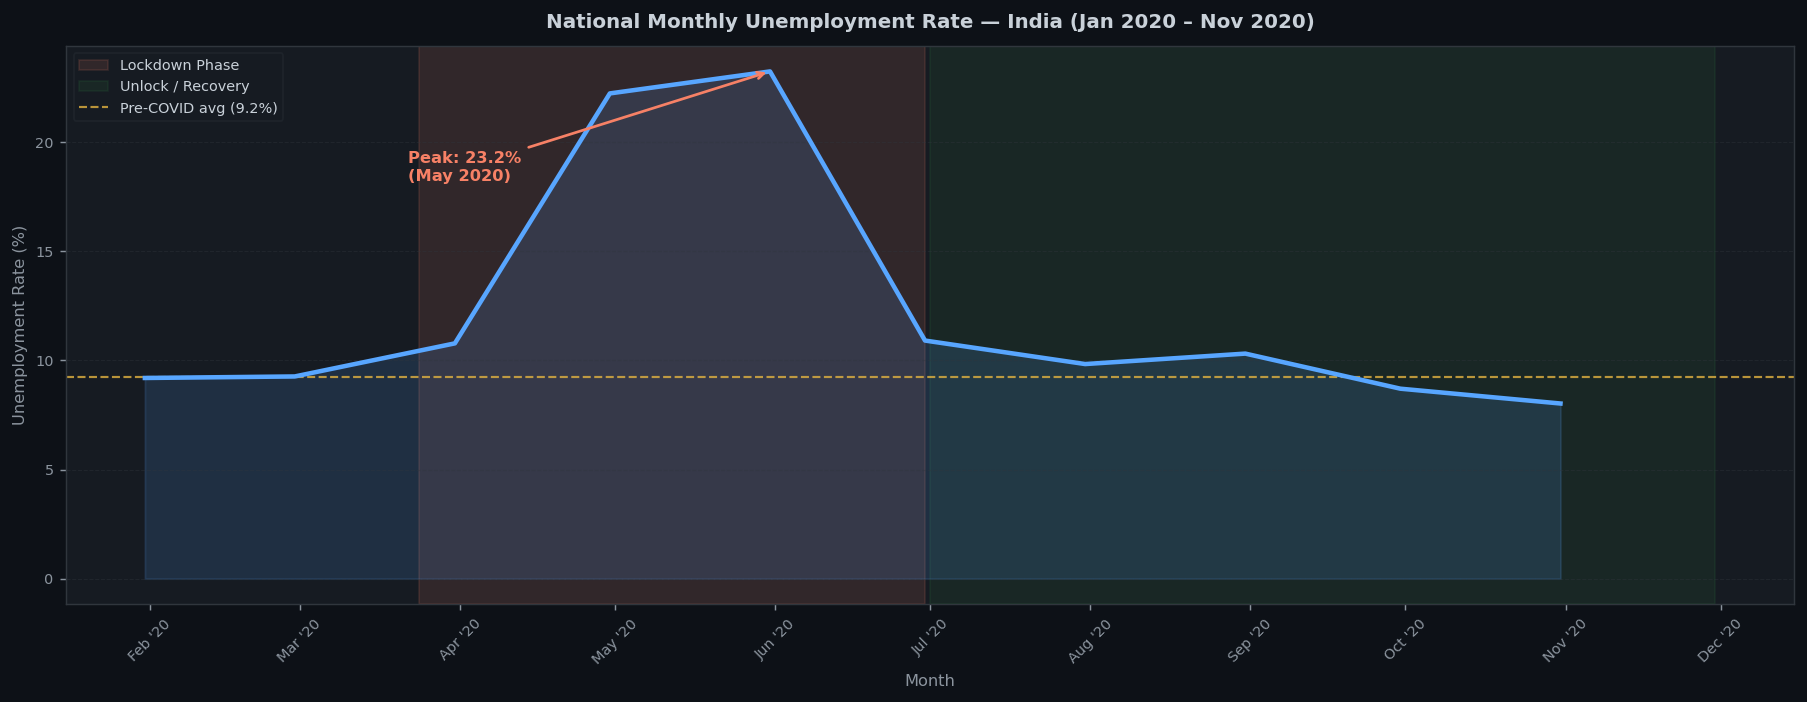

  ✔  fig1_national_trend.png saved


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. VISUALISATIONS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  STEP 3 — GENERATING VISUALISATIONS  (5 figures)")
print("=" * 65)


# ─── Helper ──────────────────────────────────────────────────────────────────
def style_ax(ax, title="", xlabel="", ylabel="", grid=True):
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10,
                 color=PALETTE["text"])
    ax.set_xlabel(xlabel, fontsize=9, color=PALETTE["subtext"])
    ax.set_ylabel(ylabel, fontsize=9, color=PALETTE["subtext"])
    if grid:
        ax.grid(True, axis="y", alpha=0.4)
    ax.tick_params(colors=PALETTE["subtext"], labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE["border"])


# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — National Unemployment Trend with COVID-19 phases
# ═══════════════════════════════════════════════════════════════════════════
monthly_nat = (df2.groupby("Date")["Unemployment_Rate"]
               .mean().reset_index().sort_values("Date"))

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor(PALETTE["bg"])
ax.set_facecolor(PALETTE["panel"])

# Phase shading
ax.axvspan(pd.Timestamp("2020-03-24"), pd.Timestamp("2020-06-30"),
           color=PALETTE["accent2"], alpha=0.12, label="Lockdown Phase")
ax.axvspan(pd.Timestamp("2020-07-01"), pd.Timestamp("2020-11-30"),
           color=PALETTE["accent3"], alpha=0.08, label="Unlock / Recovery")

ax.plot(monthly_nat["Date"], monthly_nat["Unemployment_Rate"],
        color=PALETTE["accent1"], linewidth=2.5, zorder=3)
ax.fill_between(monthly_nat["Date"], monthly_nat["Unemployment_Rate"],
                alpha=0.15, color=PALETTE["accent1"])

# Peak annotation
peak_row = monthly_nat.loc[monthly_nat["Unemployment_Rate"].idxmax()]
ax.annotate(
    f"Peak: {peak_row['Unemployment_Rate']:.1f}%\n({peak_row['Date'].strftime('%b %Y')})",
    xy=(peak_row["Date"], peak_row["Unemployment_Rate"]),
    xytext=(peak_row["Date"] - pd.Timedelta(days=70),
            peak_row["Unemployment_Rate"] - 5),
    arrowprops=dict(arrowstyle="->", color=PALETTE["accent2"], lw=1.5),
    fontsize=9, color=PALETTE["accent2"], fontweight="bold",
)

ax.axhline(pre_covid, color=PALETTE["highlight"], linewidth=1.2,
           linestyle="--", alpha=0.8, label=f"Pre-COVID avg ({pre_covid:.1f}%)")

style_ax(ax,
         title="National Monthly Unemployment Rate — India (Jan 2020 – Nov 2020)",
         xlabel="Month", ylabel="Unemployment Rate (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

legend = ax.legend(fontsize=8, loc="upper left",
                   facecolor=PALETTE["panel"], edgecolor=PALETTE["border"])
for text in legend.get_texts():
    text.set_color(PALETTE["text"])

plt.tight_layout()
plt.savefig("fig1_national_trend.png", dpi=150, bbox_inches="tight",
            facecolor=PALETTE["bg"])
plt.show()
print("  ✔  fig1_national_trend.png saved")



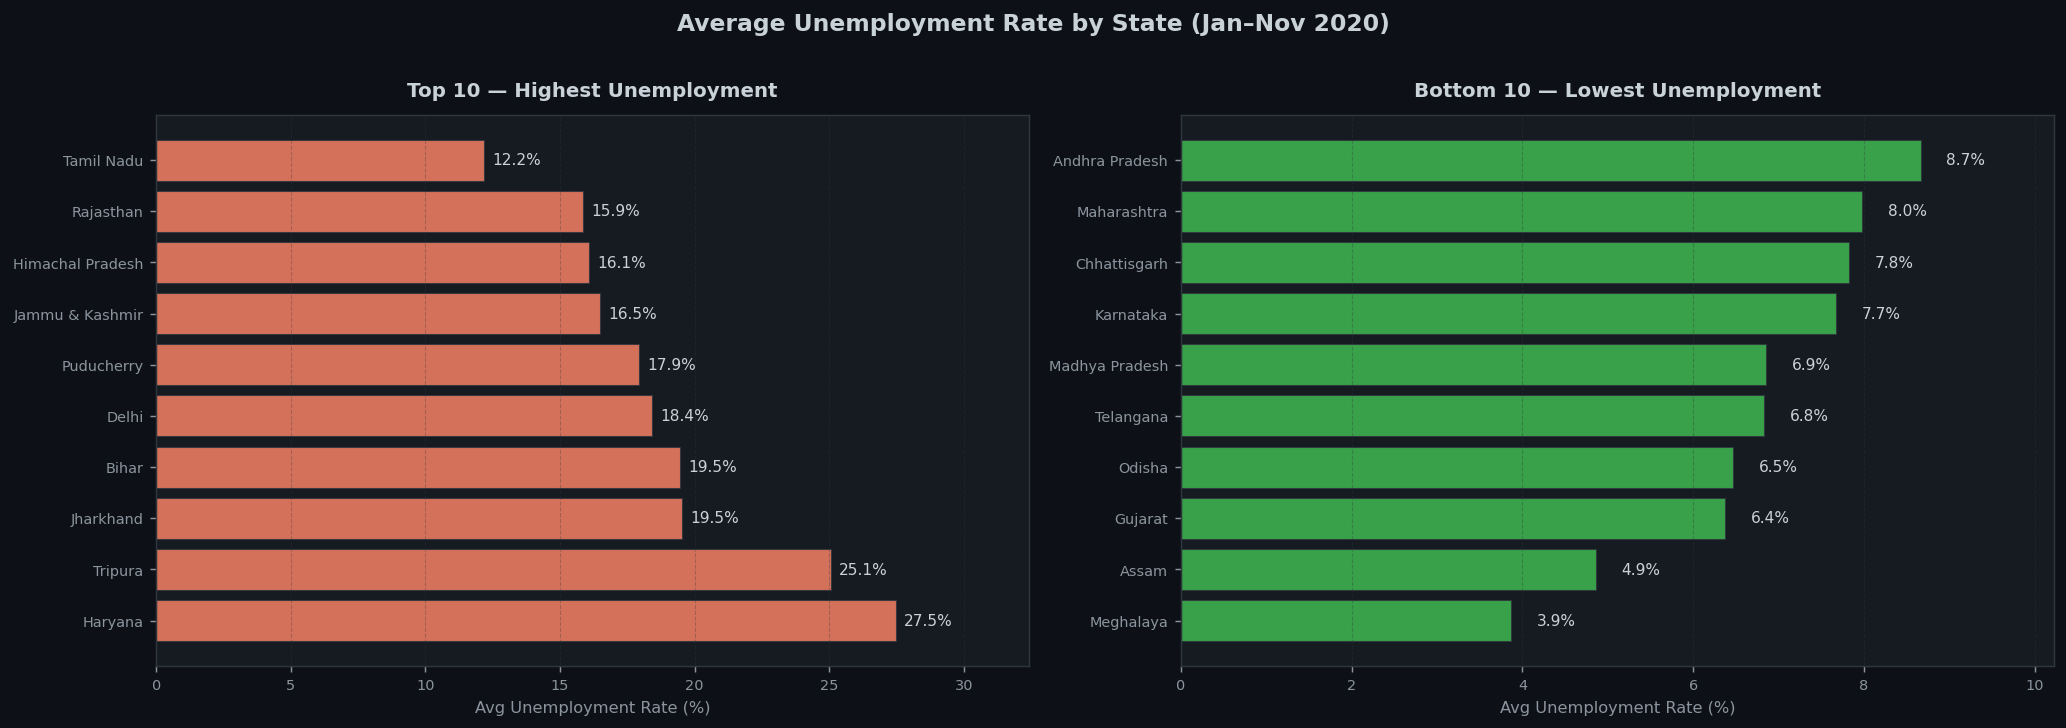

  ✔  fig2_state_ranking.png saved


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Top-10 & Bottom-10 States by average unemployment
# ═══════════════════════════════════════════════════════════════════════════
state_avg = (df2.groupby("Region")["Unemployment_Rate"]
             .mean().sort_values(ascending=False))
top10    = state_avg.head(10)
bottom10 = state_avg.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(PALETTE["bg"])
fig.suptitle("Average Unemployment Rate by State (Jan–Nov 2020)",
             fontsize=13, fontweight="bold", color=PALETTE["text"], y=1.01)

for ax, data, title, color in zip(
    axes,
    [top10, bottom10.sort_values()],
    ["Top 10 — Highest Unemployment", "Bottom 10 — Lowest Unemployment"],
    [PALETTE["accent2"], PALETTE["accent3"]],
):
    ax.set_facecolor(PALETTE["panel"])
    bars = ax.barh(data.index, data.values, color=color, alpha=0.85,
                   edgecolor=PALETTE["border"], linewidth=0.6)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=8.5,
                color=PALETTE["text"])
    style_ax(ax, title=title, xlabel="Avg Unemployment Rate (%)", grid=False)
    ax.set_xlim(0, data.max() * 1.18)
    ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("fig2_state_ranking.png", dpi=150, bbox_inches="tight",
            facecolor=PALETTE["bg"])
plt.show()
print("  ✔  fig2_state_ranking.png saved")



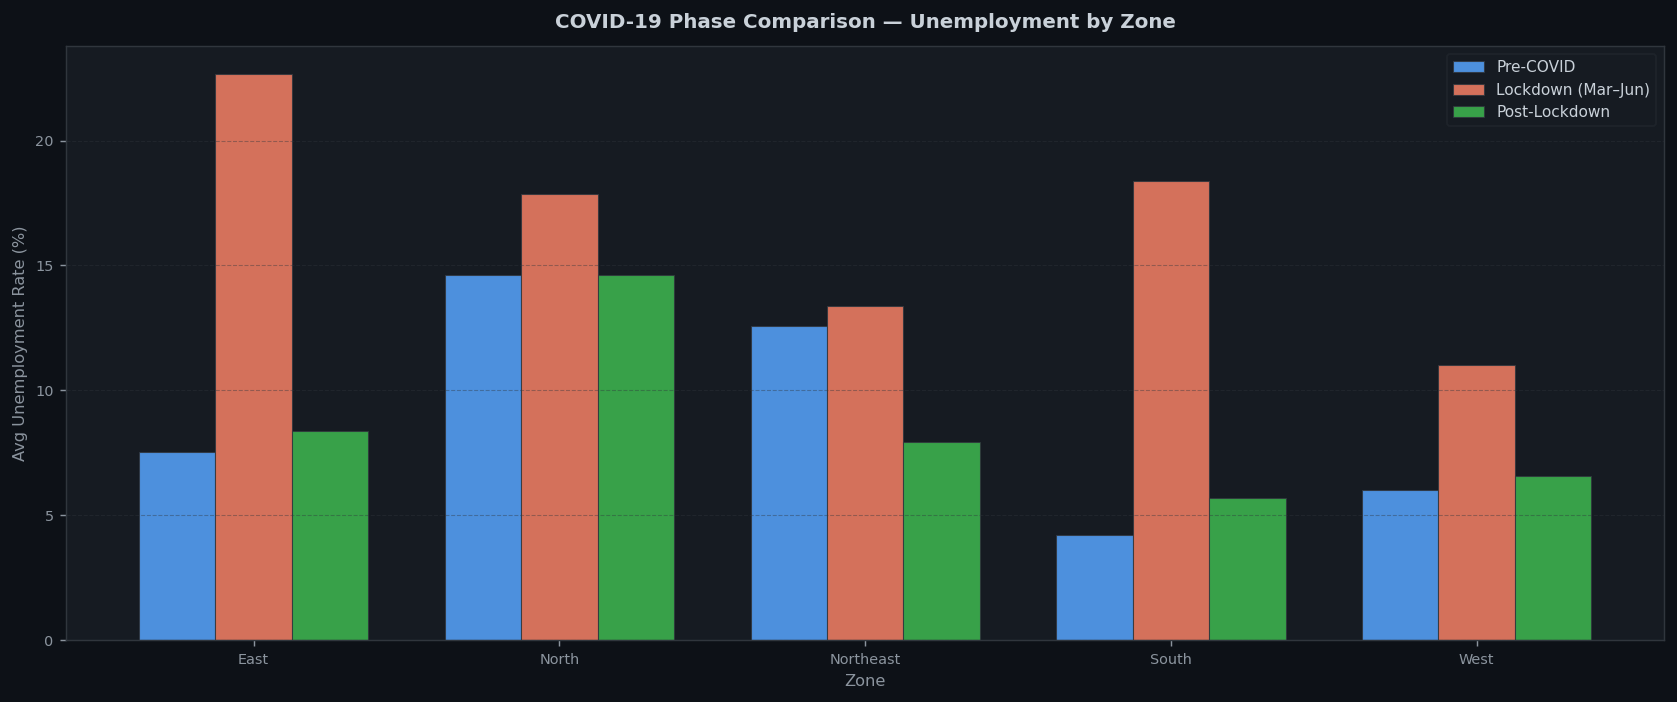

  ✔  fig3_phase_by_zone.png saved


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 — COVID-19 Impact: Pre vs Lockdown vs Post by Zone
# ═══════════════════════════════════════════════════════════════════════════
df2["Phase"] = pd.cut(
    df2["Date"],
    bins=[pd.Timestamp("2019-01-01"),
          pd.Timestamp("2020-02-29"),
          pd.Timestamp("2020-06-30"),
          pd.Timestamp("2021-01-01")],
    labels=["Pre-COVID", "Lockdown (Mar–Jun)", "Post-Lockdown"],
)

zone_phase = (df2.groupby(["Zone", "Phase"], observed=True)["Unemployment_Rate"]
              .mean().unstack("Phase"))

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor(PALETTE["bg"])
ax.set_facecolor(PALETTE["panel"])

x      = np.arange(len(zone_phase.index))
width  = 0.25
colors = [PALETTE["accent1"], PALETTE["accent2"], PALETTE["accent3"]]

for i, (col, color) in enumerate(zip(zone_phase.columns, colors)):
    bars = ax.bar(x + i * width, zone_phase[col], width, label=col,
                  color=color, alpha=0.85, edgecolor=PALETTE["border"],
                  linewidth=0.6)

ax.set_xticks(x + width)
ax.set_xticklabels(zone_phase.index, fontsize=9)
style_ax(ax,
         title="COVID-19 Phase Comparison — Unemployment by Zone",
         xlabel="Zone", ylabel="Avg Unemployment Rate (%)")
legend = ax.legend(fontsize=8.5, facecolor=PALETTE["panel"],
                   edgecolor=PALETTE["border"])
for text in legend.get_texts():
    text.set_color(PALETTE["text"])

plt.tight_layout()
plt.savefig("fig3_phase_by_zone.png", dpi=150, bbox_inches="tight",
            facecolor=PALETTE["bg"])
plt.show()
print("  ✔  fig3_phase_by_zone.png saved")



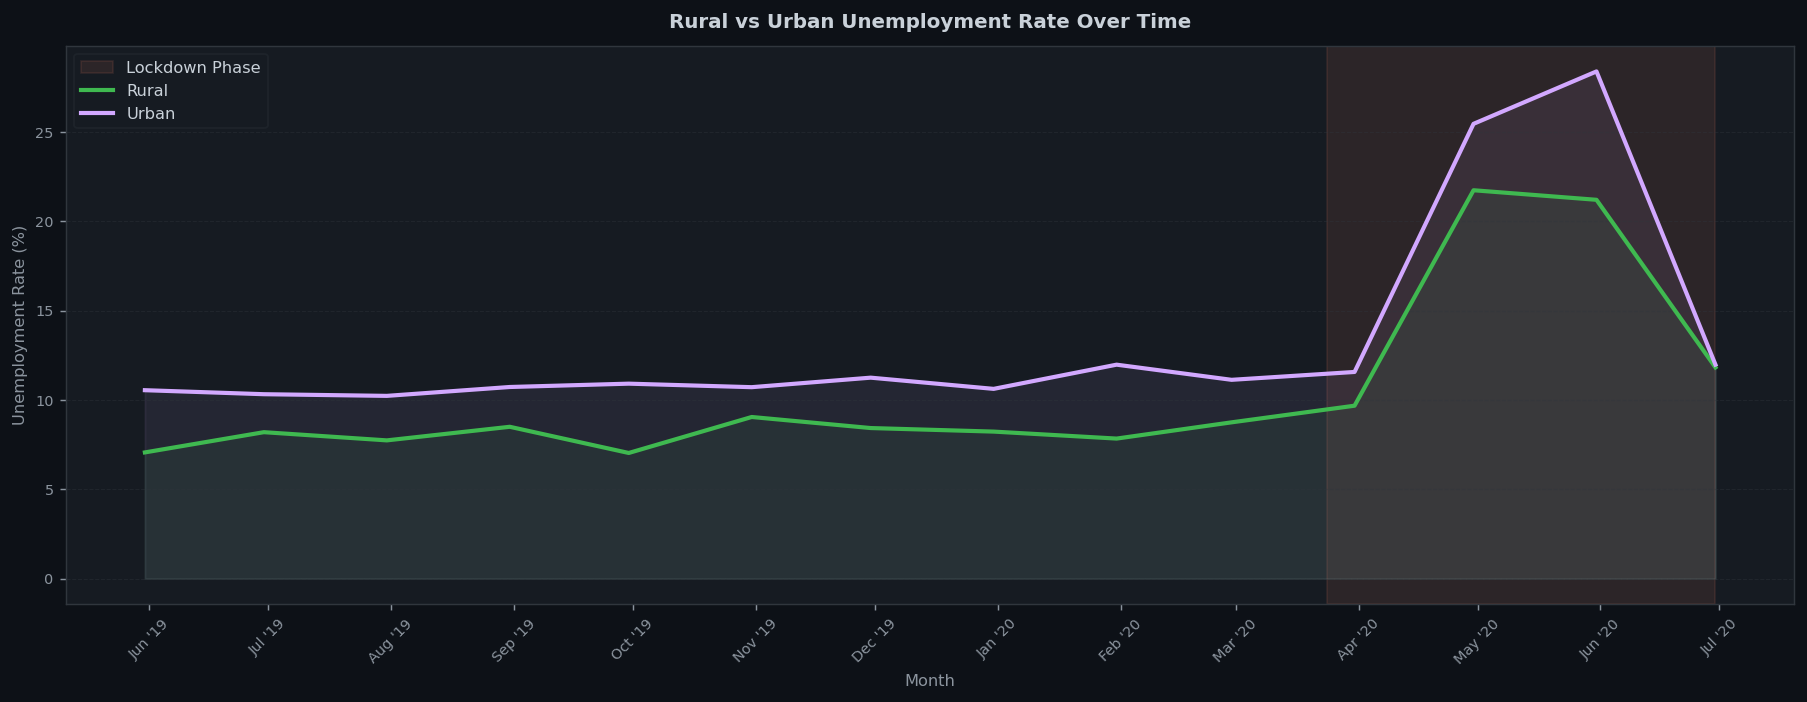

  ✔  fig4_rural_urban.png saved


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Rural vs Urban unemployment over time (Dataset 1)
# ═══════════════════════════════════════════════════════════════════════════
rural_urban_monthly = (
    df1.groupby(["Date", "Area"])["Unemployment_Rate"]
    .mean().unstack("Area").reset_index().sort_values("Date")
)

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor(PALETTE["bg"])
ax.set_facecolor(PALETTE["panel"])

ax.axvspan(pd.Timestamp("2020-03-24"), pd.Timestamp("2020-06-30"),
           color=PALETTE["accent2"], alpha=0.1, label="Lockdown Phase")

for area, color in [("Rural", PALETTE["accent3"]),
                    ("Urban", PALETTE["accent4"])]:
    if area in rural_urban_monthly.columns:
        ax.plot(rural_urban_monthly["Date"], rural_urban_monthly[area],
                color=color, linewidth=2.3, label=area, zorder=3)
        ax.fill_between(rural_urban_monthly["Date"],
                        rural_urban_monthly[area],
                        alpha=0.08, color=color)

style_ax(ax,
         title="Rural vs Urban Unemployment Rate Over Time",
         xlabel="Month", ylabel="Unemployment Rate (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
legend = ax.legend(fontsize=9, facecolor=PALETTE["panel"],
                   edgecolor=PALETTE["border"])
for text in legend.get_texts():
    text.set_color(PALETTE["text"])

plt.tight_layout()
plt.savefig("fig4_rural_urban.png", dpi=150, bbox_inches="tight",
            facecolor=PALETTE["bg"])
plt.show()
print("  ✔  fig4_rural_urban.png saved")



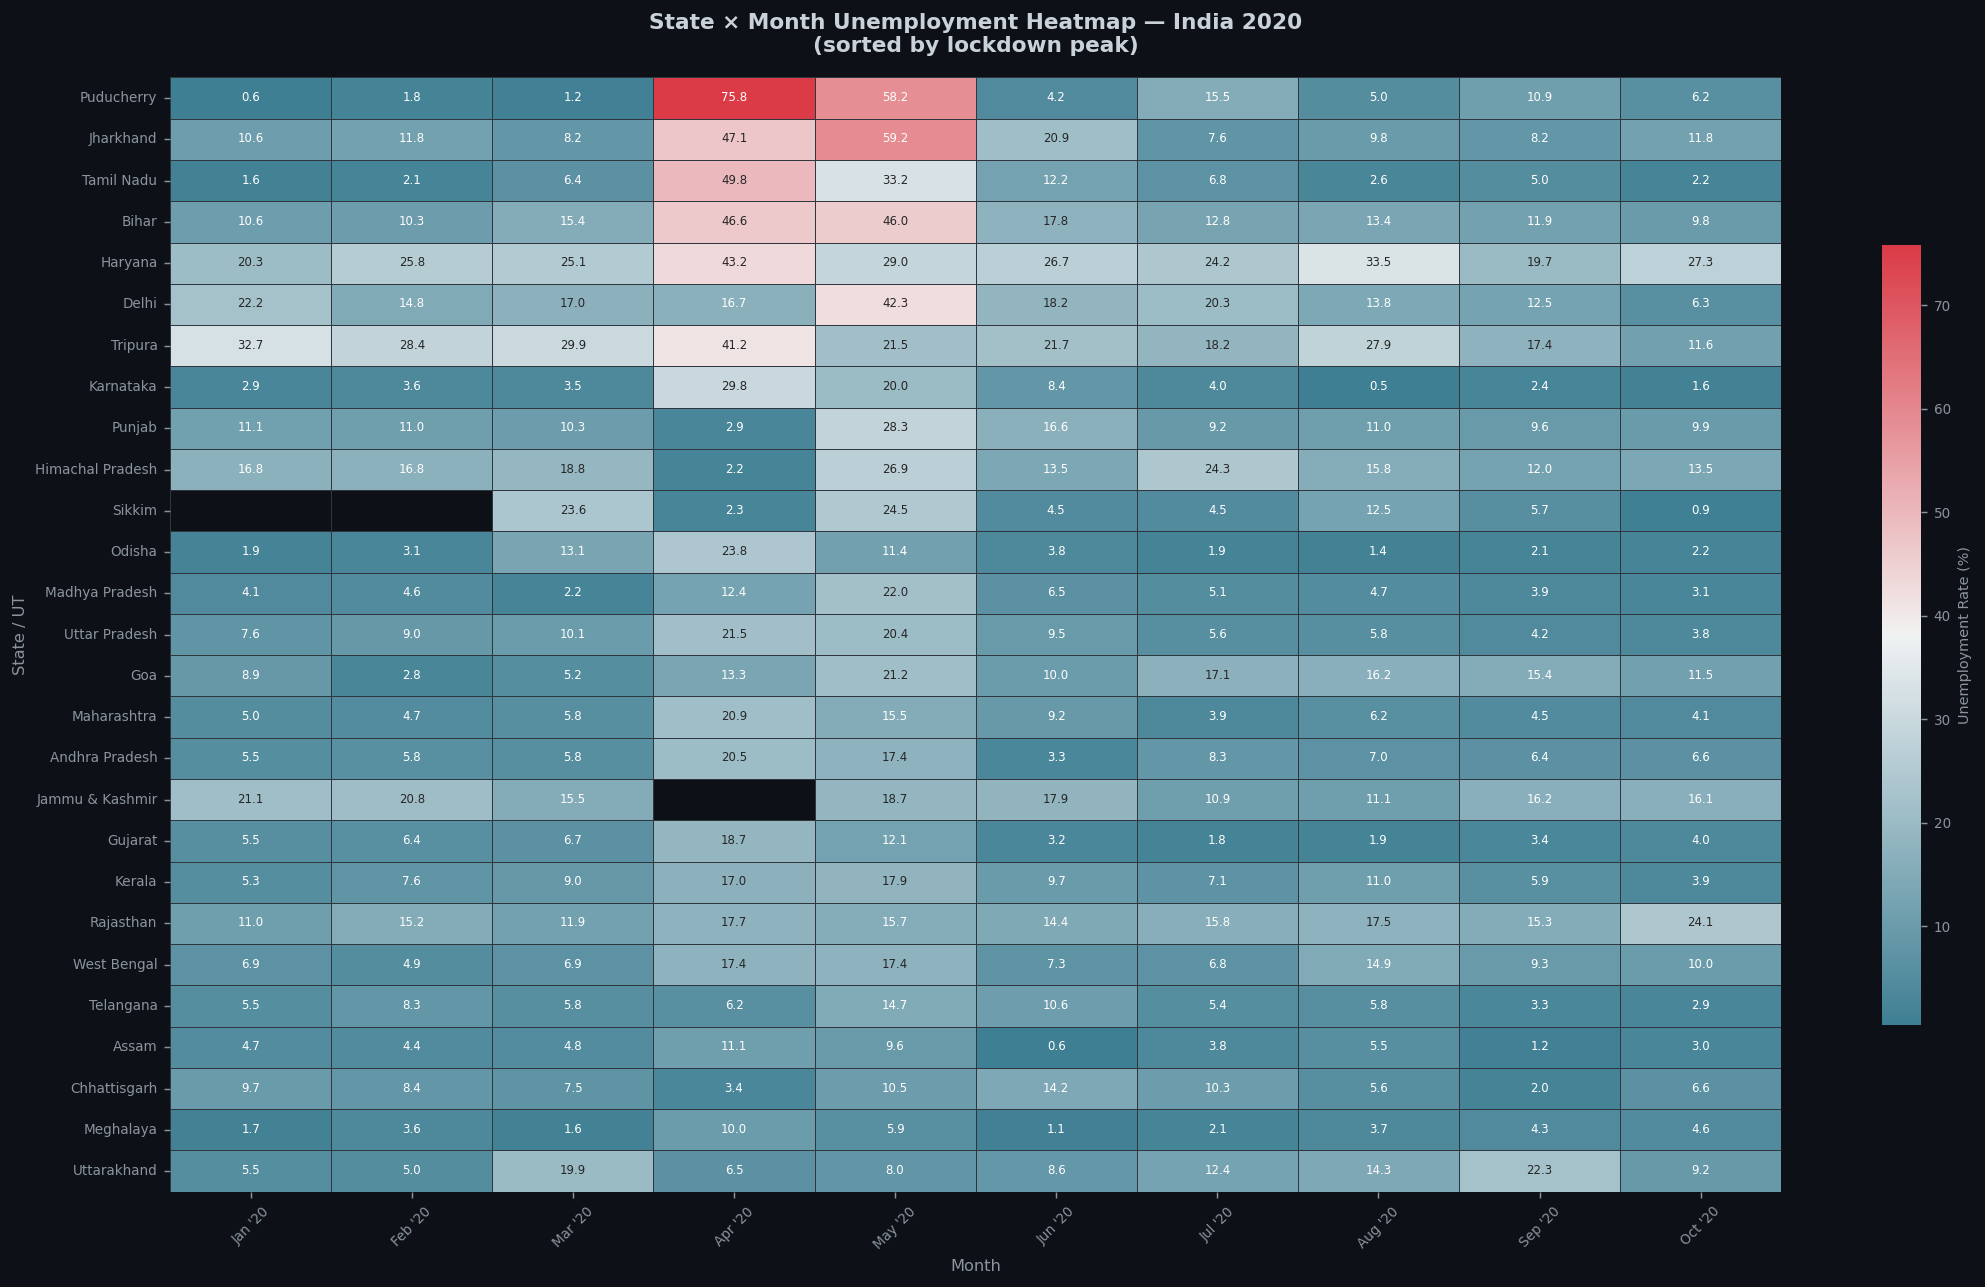

  ✔  fig5_heatmap.png saved


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Heatmap: State × Month unemployment matrix
# ═══════════════════════════════════════════════════════════════════════════
df2["MonthLabel"] = df2["Date"].dt.strftime("%b '%y")
month_order = (df2.sort_values("Date")["MonthLabel"].unique().tolist())

pivot = (df2.pivot_table(index="Region", columns="MonthLabel",
                         values="Unemployment_Rate", aggfunc="mean")
         .reindex(columns=month_order))

# Sort states by their lockdown peak (Apr or May 2020)
lockdown_cols = [c for c in month_order if c in ["Apr '20", "May '20"]]
pivot["_sort"] = pivot[lockdown_cols].max(axis=1)
pivot = pivot.sort_values("_sort", ascending=False).drop(columns="_sort")

fig, ax = plt.subplots(figsize=(17, 10))
fig.patch.set_facecolor(PALETTE["bg"])
ax.set_facecolor(PALETTE["bg"])

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    pivot, ax=ax, cmap=cmap, linewidths=0.3, linecolor=PALETTE["border"],
    annot=True, fmt=".1f", annot_kws={"size": 6.5},
    cbar_kws={"label": "Unemployment Rate (%)", "shrink": 0.7},
)
ax.set_title("State × Month Unemployment Heatmap — India 2020\n"
             "(sorted by lockdown peak)",
             fontsize=12, fontweight="bold", color=PALETTE["text"], pad=14)
ax.set_xlabel("Month", fontsize=9, color=PALETTE["subtext"])
ax.set_ylabel("State / UT", fontsize=9, color=PALETTE["subtext"])
ax.tick_params(axis="x", rotation=45, labelsize=7.5, colors=PALETTE["subtext"])
ax.tick_params(axis="y", labelsize=7.5, colors=PALETTE["subtext"])

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors=PALETTE["subtext"], labelsize=7.5)
cbar.set_label("Unemployment Rate (%)", color=PALETTE["subtext"], fontsize=8)

plt.tight_layout()
plt.savefig("fig5_heatmap.png", dpi=150, bbox_inches="tight",
            facecolor=PALETTE["bg"])
plt.show()
print("  ✔  fig5_heatmap.png saved")



In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. KEY INSIGHTS & POLICY RECOMMENDATIONS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  STEP 4 — KEY INSIGHTS & POLICY RECOMMENDATIONS")
print("=" * 65)

print("""
  ┌─────────────────────────────────────────────────────────┐
  │             KEY FINDINGS FROM THE ANALYSIS              │
  └─────────────────────────────────────────────────────────┘

  1. COVID-19 SHOCK
     • National unemployment surged from ~{:.1f}% (pre-COVID) to
       ~{:.1f}% during the Apr–May 2020 lockdown — a {:.1f}x increase.
     • Bihar, Jharkhand, Haryana & Tamil Nadu crossed 40–47% —
       the most severe spikes recorded in the dataset.

  2. UNEVEN RECOVERY
     • By Jul–Nov 2020 the average fell to ~{:.1f}%, but remained
       elevated above pre-COVID baseline by ~{:.1f} pp.
     • Northeastern and Southern states (Assam, Telangana) recovered
       faster than North-Indian states.

  3. RURAL vs URBAN DIVIDE
     • Urban unemployment was consistently higher than Rural,
       reflecting the concentration of formal sector jobs in cities.
     • Both segments spiked during lockdown, but the Urban spike
       was proportionally steeper (services/manufacturing shutdowns).

  4. SEASONAL PATTERNS
     • Even pre-COVID, Dec–Feb showed modest unemployment upticks
       (rabi harvest lag, construction slowdown in winter).
     • Post-lockdown months showed a "V-shape" recovery — quick
       in agriculture-dominant states, sluggish in urban states.

  ┌─────────────────────────────────────────────────────────┐
  │              POLICY RECOMMENDATIONS                     │
  └─────────────────────────────────────────────────────────┘

  ◆ Strengthen social safety nets (MGNREGS) with extended coverage
    in Urban areas — current mandate is rural-only.
  ◆ Fast-track MSMEs credit access during any future lockdown to
    prevent mass layoffs in manufacturing & services sectors.
  ◆ Invest in retraining & upskilling programs (digital skills)
    targeting states with persistently high unemployment (Tripura,
    Haryana, Jharkhand).
  ◆ Use labour participation rate as a leading indicator — states
    where participation fell sharply (Tamil Nadu, UP) signal
    discouraged workers who exit the labour force entirely.
  ◆ Real-time unemployment tracking systems should be mandated
    at state level to enable faster fiscal stimulus deployment.
""".format(pre_covid, lockdown, lockdown / pre_covid,
           post_covid, post_covid - pre_covid))


  STEP 4 — KEY INSIGHTS & POLICY RECOMMENDATIONS

  ┌─────────────────────────────────────────────────────────┐
  │             KEY FINDINGS FROM THE ANALYSIS              │
  └─────────────────────────────────────────────────────────┘

  1. COVID-19 SHOCK
     • National unemployment surged from ~9.2% (pre-COVID) to
       ~16.7% during the Apr–May 2020 lockdown — a 1.8x increase.
     • Bihar, Jharkhand, Haryana & Tamil Nadu crossed 40–47% —
       the most severe spikes recorded in the dataset.

  2. UNEVEN RECOVERY
     • By Jul–Nov 2020 the average fell to ~9.2%, but remained
       elevated above pre-COVID baseline by ~-0.0 pp.
     • Northeastern and Southern states (Assam, Telangana) recovered
       faster than North-Indian states.

  3. RURAL vs URBAN DIVIDE
     • Urban unemployment was consistently higher than Rural,
       reflecting the concentration of formal sector jobs in cities.
     • Both segments spiked during lockdown, but the Urban spike
       was proportionall